In [1]:
import folium

mapa = folium.Map(
    location=[20, 0],
    zoom_start=2,
    tiles="CartoDB positron"
)

paises = [
    ["Brazil", -15.7939, -47.8828, 25, "green"],
    ["Canada", 56.1304, -106.3468, -5, "blue"],
    ["India", 20.5937, 78.9629, 28, "red"],
    ["Spain", 40.4168, -3.7038, 15, "orange"]
]

for pais, lat, lon, temp, color in paises:

    folium.CircleMarker(
        location=[lat, lon],
        radius=8,
        popup=f"{pais}: {temp}°C",
        tooltip=pais,
        color=color,
        fill=True,
        fill_color=color

    ).add_to(mapa)

mapa

## 2. Exploración inicial del dataset

Vamos a inspeccionar la estructura general de los datos:
- número de filas y columnas
- tipos de datos
- valores nulos
- primeras observaciones

# 🌍 Global Temperature Analysis

Este notebook analiza datos históricos de temperatura media por país.

El objetivo es practicar un flujo completo de análisis de datos:

- carga del dataset
- exploración inicial
- limpieza de datos
- tratamiento de fechas
- análisis por país
- análisis temporal
- visualizaciones
- conclusiones

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carga del dataset

Cargamos el archivo `GlobalLandTemperaturesByCountry.csv`, que contiene información histórica de temperaturas medias por país.

In [3]:
df = pd.read_csv("../../datasets/GlobalLandTemperaturesByCountry.csv")

In [4]:
df.head()

,dt,AverageTemperature,AverageTemperatureUncertainty,Country
0,1743-11-01,4.384,2.294,Åland
1,1743-12-01,NaN,NaN,Åland
2,1744-01-01,NaN,NaN,Åland
3,1744-02-01,NaN,NaN,Åland
4,1744-03-01,NaN,NaN,Åland


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577462 entries, 0 to 577461
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   dt                             577462 non-null  str    
 1   AverageTemperature             544811 non-null  float64
 2   AverageTemperatureUncertainty  545550 non-null  float64
 3   Country                        577462 non-null  str    
dtypes: float64(2), str(2)
memory usage: 17.6 MB


In [6]:
df.shape

(577462, 4)

## 2. Exploración inicial del dataset

Vamos a inspeccionar la estructura general de los datos:
- número de filas y columnas
- tipos de datos
- valores nulos
- primeras observaciones

In [7]:
df.isnull().sum()

dt                                   0
AverageTemperature               32651
AverageTemperatureUncertainty    31912
Country                              0
dtype: int64

## 3. Limpieza de datos

El dataset contiene valores nulos en las columnas relacionadas con temperatura.

Vamos a eliminarlos para trabajar únicamente con registros válidos.

In [8]:
df = df.dropna()

In [9]:
df.isnull().sum()

dt                               0
AverageTemperature               0
AverageTemperatureUncertainty    0
Country                          0
dtype: int64

## 4. Conversión de fechas

La columna `dt` está almacenada como texto.

Vamos a convertirla a formato datetime para poder realizar análisis temporales.

In [10]:
df['dt'] = pd.to_datetime(df['dt'])

In [11]:
df.info()

<class 'pandas.DataFrame'>
Index: 544811 entries, 0 to 577460
Data columns (total 4 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   dt                             544811 non-null  datetime64[us]
 1   AverageTemperature             544811 non-null  float64       
 2   AverageTemperatureUncertainty  544811 non-null  float64       
 3   Country                        544811 non-null  str           
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 20.8 MB


In [12]:
df['Year'] = df['dt'].dt.year

In [13]:
df[['dt', 'Year']].head()

,dt,Year
0,1743-11-01,1743
5,1744-04-01,1744
6,1744-05-01,1744
7,1744-06-01,1744
8,1744-07-01,1744


## 5. Evolución de la temperatura media global

Calculamos la temperatura media por año para analizar tendencias climáticas a lo largo del tiempo.

In [14]:
temp_year = df.groupby('Year')['AverageTemperature'].mean()

In [15]:
temp_year.head()

Year
1743    5.184140
1744    9.837898
1745    1.387125
1750    9.129353
1751    9.167388
Name: AverageTemperature, dtype: float64

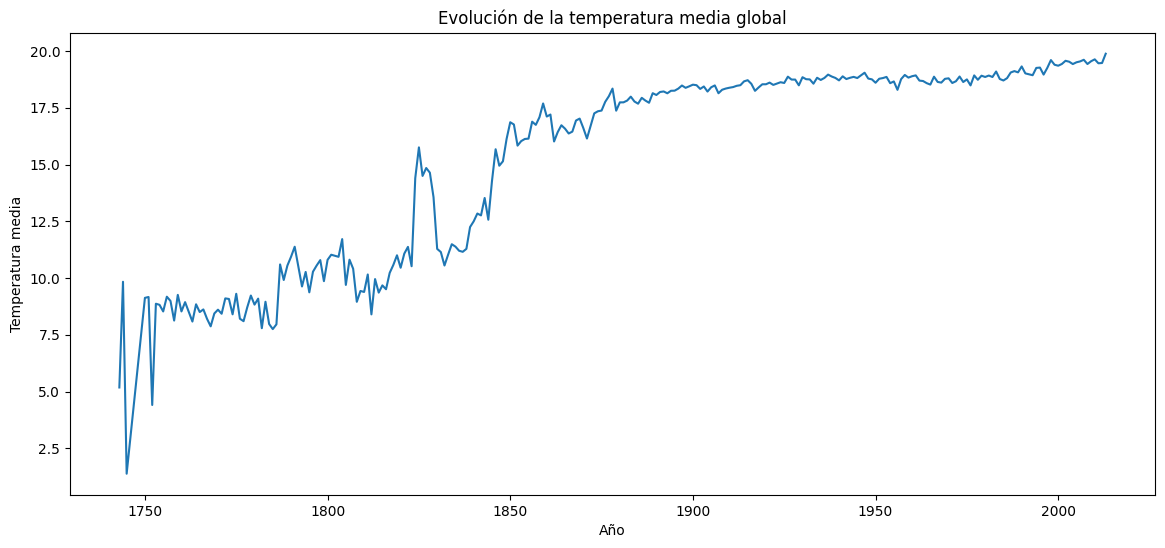

In [16]:
plt.figure(figsize=(14,6))

plt.plot(temp_year.index, temp_year.values)

plt.title("Evolución de la temperatura media global")
plt.xlabel("Año")
plt.ylabel("Temperatura media")

plt.show()

## 6. Comparación de temperatura media por países

En esta sección vamos a comparar la evolución de la temperatura media anual en varios países seleccionados.

In [17]:
paises = ["Spain", "Canada", "Brazil", "India"]

df_paises = df[df["Country"].isin(paises)]

temp_paises = (
    df_paises
    .groupby(["Year", "Country"])["AverageTemperature"]
    .mean()
    .reset_index()
)

temp_paises.head()

,Year,Country,AverageTemperature
0,1743,Spain,9.346000
1,1744,Spain,14.537375
2,1745,Spain,7.931750
3,1750,Spain,14.120636
4,1751,Spain,14.710375


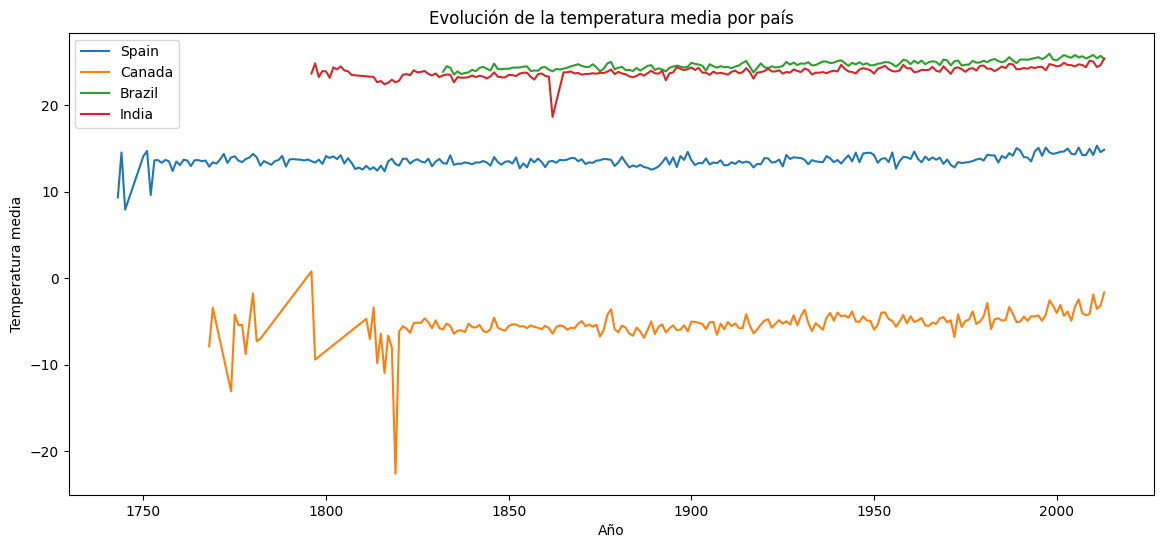

In [18]:
plt.figure(figsize=(14,6))

for pais in paises:
    datos_pais = temp_paises[temp_paises["Country"] == pais]
    plt.plot(datos_pais["Year"], datos_pais["AverageTemperature"], label=pais)

plt.title("Evolución de la temperatura media por país")
plt.xlabel("Año")
plt.ylabel("Temperatura media")
plt.legend()
plt.show()

## 7. Correlación entre variables numéricas

Analizamos la relación entre las variables numéricas del dataset mediante un heatmap.

In [20]:
corr = df[['AverageTemperature', 'AverageTemperatureUncertainty', 'Year']].corr()

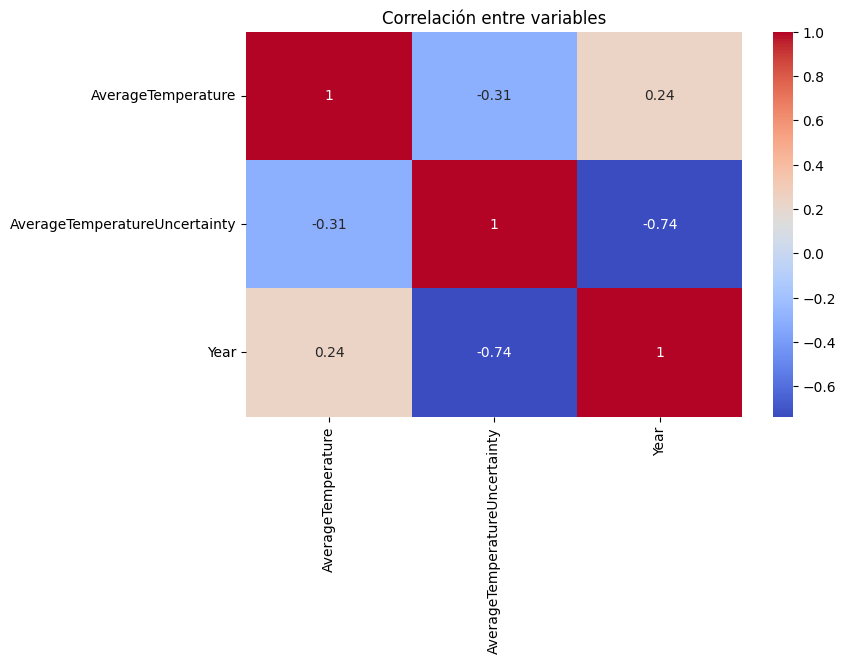

In [22]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlación entre variables")

plt.show()

## 📊 Interpretación del heatmap de correlación

El heatmap muestra la relación entre las principales variables numéricas del dataset climático.

### Principales conclusiones:

- Existe una correlación positiva entre el año y la temperatura media (`0.24`), lo que sugiere una tendencia general de aumento de temperaturas a lo largo del tiempo.

- La incertidumbre de las mediciones presenta una fuerte correlación negativa con el año (`-0.74`). Esto indica que las mediciones modernas son considerablemente más precisas que las históricas.

- La relación entre temperatura media e incertidumbre es moderadamente negativa (`-0.31`), aunque no representa la conclusión principal del análisis.

En conjunto, los datos reflejan tanto una mejora progresiva en la calidad de las mediciones climáticas como una tendencia ascendente de la temperatura global.